# Solar Energy Forecast

We'll first perform solar energy forecast. Daily Day ahead Energy forecast(aggregate) then map it to the hourly.

# Importing Basic Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [2]:
def load_and_prepare_energy_data(filepath: str):
    """
    Reads raw energy production dataset and returns cleaned
    solar, wind, and mixed DataFrames.

    Steps performed:
    - Parse Date and hour columns
    - Create hourly datetime index
    - Aggregate duplicate timestamps
    - Remove duplicates
    - Log transform Production
    - Split by Source
    """

    # 1️⃣ Read data
    df = pd.read_csv(
        filepath,
        dtype={
            "Date": "string",
            "Start_Hour": "int64",
            "End_Hour": "int64"
        }
    )

    # 2️⃣ Create datetime index
    df["start_datetime"] = (
        pd.to_datetime(df["Date"], format="%m/%d/%Y")
        + pd.to_timedelta(df["Start_Hour"], unit="h")
    )

    df = df.set_index("start_datetime")
    df = df.sort_index()

    # 3️⃣ Aggregate duplicate timestamps (hour-level)
    df["Production"] = (
        df["Production"]
        .groupby(level=0)
        .transform("sum")
    )

    # 4️⃣ Remove duplicates after aggregation
    df = df[~df.index.duplicated(keep="first")]

    # 5️⃣ Log transformation (handle zero safely)
    df["Production_ln"] = np.log1p(df["Production"])

    # 6️⃣ Split by source
    wind = df[df["Source"] == "Wind"].copy()
    solar = df[df["Source"] == "Solar"].copy()
    mixed = df[df["Source"] == "Mixed"].copy()

    return solar, wind, mixed

In [3]:
solar, wind, mixed = load_and_prepare_energy_data(
    "Energy Production Dataset.csv"
)

# Elementary Data Analysis

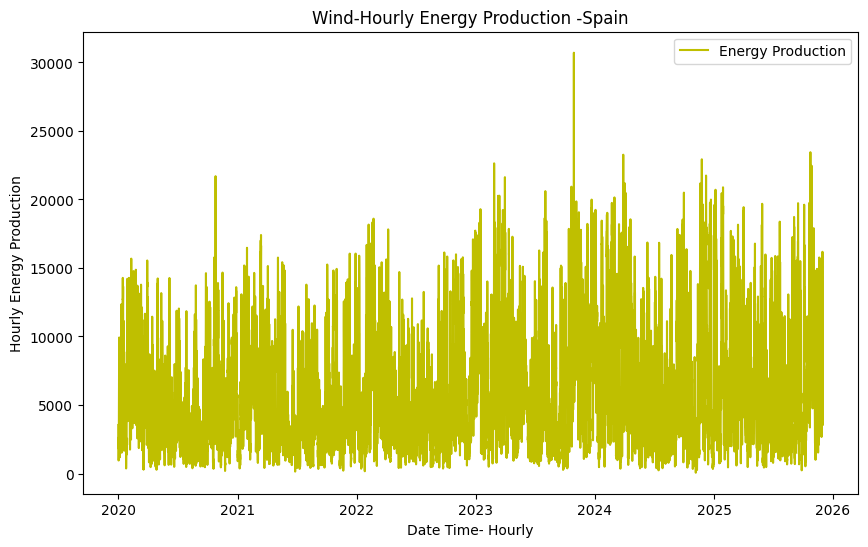

In [4]:
plt.figure(figsize=(10,6))
plt.plot(wind.index ,wind['Production'], color = 'y' ,label = 'Energy Production')
plt.xlabel('Date Time- Hourly')
plt.ylabel('Hourly Energy Production')
plt.title('Wind-Hourly Energy Production -Spain')
plt.legend(loc= 'best')
plt.show()

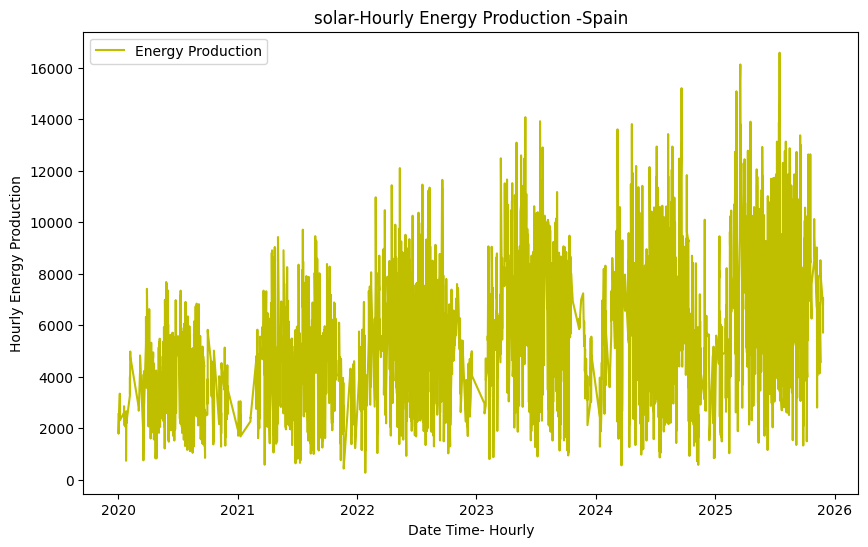

In [5]:
plt.figure(figsize=(10,6))
plt.plot(solar.index ,solar['Production'], color = 'y' ,label = 'Energy Production')
plt.xlabel('Date Time- Hourly')
plt.ylabel('Hourly Energy Production')
plt.title('solar-Hourly Energy Production -Spain')
plt.legend(loc= 'best')
plt.show()

Plot shows clear trend+ Multi Seasonality( Yearly, Monthly, Daily etc). Since seasonality also changes with increasing trend, hence we can conclude this
is multiplicative modelling scenario. We'll go ahead with modeling in log space making it a additive model

In [6]:
import plotly.graph_objects as go
def plot_monthly_production_interactive(df, source_name="Solar"):
    """
    Creates interactive monthly production plot with:
    - Year-wise traces
    - Season filter dropdown
    - Day filter dropdown
    
    Parameters
    ----------
    df : DataFrame (must contain index datetime + Production + Season + Day_Name + Month_Name)
    source_name : str (for title labeling)

    Returns
    -------
    fig : plotly.graph_objects.Figure
    """

    MONTH_ORDER = [
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ]

    def prepare_monthly(data, season=None, day_name=None):
        temp = data.copy()
        temp['year'] = temp.index.year

        if season is not None:
            temp = temp[temp['Season'] == season]

        if day_name is not None:
            temp = temp[temp['Day_Name'] == day_name]

        monthly = (
            temp
            .groupby(['year', 'Month_Name'], as_index=False)['Production']
            .sum()
        )

        monthly['Month_Name'] = pd.Categorical(
            monthly['Month_Name'],
            categories=MONTH_ORDER,
            ordered=True
        )

        return monthly


    fig = go.Figure()

    monthly = prepare_monthly(df)

    BASE_Y = []

    for year in sorted(monthly['year'].unique()):
        df_y = monthly[monthly['year'] == year]

        df_y = (
            df_y
            .set_index('Month_Name')
            .reindex(MONTH_ORDER)
            .reset_index()
        )

        BASE_Y.append(df_y['Production'])

        fig.add_trace(go.Scatter(
            x=df_y['Month_Name'],
            y=df_y['Production'],
            mode='markers',
            name=str(year),
            connectgaps=False
        ))


    # -----------------------
    # Season Buttons
    # -----------------------
    seasons = sorted(df['Season'].dropna().unique())

    season_buttons = [
        dict(
            label='All Seasons',
            method='update',
            args=[
                {'y': BASE_Y},
                {'title': f'Monthly {source_name} Production - All Seasons'}
            ]
        )
    ]

    for s in seasons:
        filtered = prepare_monthly(df, season=s)

        season_buttons.append(
            dict(
                label=s,
                method='update',
                args=[
                    {'y': [
                        (
                            filtered[filtered['year'] == int(t.name)]
                            .set_index('Month_Name')
                            .reindex(MONTH_ORDER)['Production']
                        )
                        for t in fig.data
                    ]},
                    {'title': f'Monthly {source_name} Production - {s}'}
                ]
            )
        )


    # -----------------------
    # Day Buttons
    # -----------------------
    days = sorted(df['Day_Name'].dropna().unique())

    day_buttons = [
        dict(
            label='All Days',
            method='update',
            args=[
                {'y': BASE_Y},
                {'title': f'Monthly {source_name} Production - All Days'}
            ]
        )
    ]

    for d in days:
        filtered = prepare_monthly(df, day_name=d)

        day_buttons.append(
            dict(
                label=d,
                method='update',
                args=[
                    {'y': [
                        (
                            filtered[filtered['year'] == int(t.name)]
                            .set_index('Month_Name')
                            .reindex(MONTH_ORDER)['Production']
                        )
                        for t in fig.data
                    ]},
                    {'title': f'Monthly {source_name} Production - {d}'}
                ]
            )
        )


    fig.update_layout(
        xaxis=dict(
            categoryorder='array',
            categoryarray=MONTH_ORDER
        ),
        updatemenus=[
            dict(buttons=season_buttons, x=1.05, y=1.35),
            dict(buttons=day_buttons, x=1.35, y=1.35),
        ],
        xaxis_title='Month',
        yaxis_title=f'{source_name} Production',
        title=f'Monthly {source_name} Production - All',
        hovermode='x unified'
    )

    return fig

In [7]:
fig = plot_monthly_production_interactive(solar, source_name="Solar")
fig.show()

###### EDA Observations:

1. Solar production missing at night hours.

2. Solar production missing at day hours as well for some days/year/month.

3. Solar production missing for entire 24 hours for some day.

Reason: might be because of cloudy day/data gathering issue/curtailment or  some other operational causes like capacity capping etc.

# Data Split- Train,Validation & Test

In [8]:
def time_series_train_val_test_split(
    df,
    train_end="2023-12-31",
    val_end="2024-12-31",
    freq="h"
):
    """
    Reindexes time series to full hourly index and performs
    chronological train/val/test split.

    Parameters
    ----------
    df : DataFrame (must have datetime index + Production column)
    train_end : str (end date for training set)
    val_end : str (end date for validation set)
    freq : str (time frequency, default = 'h')

    Returns
    -------
    train, val, test : DataFrames
    """

    # 1️⃣ Create continuous time index
    full_idx = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq=freq
    )

    df_full = df.reindex(full_idx)

    # 2️⃣ Chronological split
    train = df_full.loc[:train_end].copy()
    val   = df_full.loc[pd.to_datetime(train_end) + pd.Timedelta(hours=1):val_end].copy()
    test  = df_full.loc[pd.to_datetime(val_end) + pd.Timedelta(hours=1):].copy()

    # 3️⃣ Mark observed vs missing production
    for subset in (train, val, test):
        subset["_is_observed"] = subset["Production"].notna()

    return train, val, test

In [9]:
train, val, test = time_series_train_val_test_split(solar)

# Data Imputation

## Creating Masks

In [10]:
## Daylight mask logic has been created with referece to the Spain-timezone/season
def create_daylight_mask(df: pd.DataFrame) -> pd.Series:
    """
    Returns a boolean Series indexed exactly like df.index
    indicating daylight hours for solar production (France).
    """

    # Extract once (no need to wrap again in Series)
    hour = df.index.hour
    month = df.index.month

    is_daylight = (
        (
            (((month <= 2) | (month == 12)) & (hour >= 9) & (hour <= 16))
            |
            ((month >= 3) & (month <= 4) & (hour >= 8) & (hour <= 18))
            |
            ((month >= 5) & (month <= 8) & (hour >= 7) & (hour <= 20))
            |
            ((month >= 9) & (month <= 10) & (hour >= 8) & (hour <= 18))
            |
            ((month == 11) & (hour >= 8) & (hour <= 17))
        )
    )

    # 🔒 HARD GUARANTEES
    is_daylight = pd.Series(is_daylight, index=df.index, dtype=bool)

    return is_daylight


In [11]:
def create_full_day_missing_mask(df:pd.DataFrame(), production_column:str = "Production") -> pd.Series():
    missing_days = (
    df[production_column]
    .isna()
    .groupby(train.index.date)
    .sum()
    )
    ## All 24 hours data missing
    missing_days = missing_days[missing_days == 24]
    # mask for full day missing (24hrs)
    is_full_day_missing = pd.Index(df.index.date).isin(missing_days.index)
    is_full_day_missing = pd.Series(
        is_full_day_missing,
        index=df.index
    )
    return is_full_day_missing

In [12]:
def impute_solar_hourly(
    df,
    hourly_weights,
    train_daily_climatology,
    production_col="Production",
):
    """
    Impute solar production with correct ordering:
    1. Full-day missing (daylight only) using TRAIN climatology
    2. Night hours → 0
    3. Partial-day daylight missing using same-day observed totals

    Parameters
    ----------
    df : pd.DataFrame
        Hourly solar dataframe (validation or test)
    hourly_weights : pd.Series
        Index = (month, hour), values sum to 1 per month (from TRAIN)
    train_daily_climatology : pd.Series
        Index = month, values = typical daily solar total (from TRAIN)- median_daily_by_month  Median profile by daily
    production_col : str
        Column name for solar production

    Returns
    -------
    df : pd.DataFrame
        Imputed dataframe (copy)
    """

    df = df.copy()
    is_daylight = create_daylight_mask(df)
    # ------------------------------------------------------------------
    # Precompute helpers
    # ------------------------------------------------------------------
    df["_date"] = df.index.date
    df["_month"] = df.index.month
    df["_hour"] = df.index.hour

    # ------------------------------------------------------------------
    # Identify full-day missing days (ALL 24 hours missing)
    # ------------------------------------------------------------------
    daily_missing_count = (
        df[production_col]
        .isna()
        .groupby(df["_date"])
        .sum()
    )

    full_missing_days = daily_missing_count[daily_missing_count == 24].index
    is_full_day_missing = df["_date"].isin(full_missing_days)

    # ------------------------------------------------------------------
    # STEP 1: Full-day missing → impute DAYLIGHT hours only
    # ------------------------------------------------------------------
    mask_full_day_daylight = (
        is_full_day_missing
        & is_daylight
        & df[production_col].isna()
    )

    if mask_full_day_daylight.any():
        # Map (month, hour) → hourly weight
        keys = list(zip(df.loc[mask_full_day_daylight, "_month"],
                        df.loc[mask_full_day_daylight, "_hour"]))
        df.loc[mask_full_day_daylight, "_hourly_weight"] = (
            pd.Series(keys, index=df.index[mask_full_day_daylight])
            .map(hourly_weights)
        )

        # Daily total from TRAIN climatology
        df.loc[mask_full_day_daylight, "_daily_total"] = (
            df.loc[mask_full_day_daylight, "_month"]
            .map(train_daily_climatology)
        )
        has_weight = df["_hourly_weight"].notna()
        df.loc[mask_full_day_daylight, production_col] = (
            df.loc[mask_full_day_daylight, "_hourly_weight"]
            * df.loc[mask_full_day_daylight, "_daily_total"]
        )

    # ------------------------------------------------------------------
    # STEP 2: Night hours → 0 (SAFE after step 1)
    # ------------------------------------------------------------------
    night_mask = (
    df[production_col].isna()
    & ~has_weight
    )
    
    df.loc[night_mask, production_col] = 0

    # ------------------------------------------------------------------
    # STEP 3: Partial-day daylight missing
    # ------------------------------------------------------------------
    mask_partial_daylight = (
        df[production_col].isna()
        & is_daylight
        & ~is_full_day_missing
    )

    if mask_partial_daylight.any():
        # Same-day observed daily total (after night zeroing)
        daily_totals = (
            df
            .groupby("_date")[production_col]
            .transform("sum")
        )

        keys = list(zip(df.loc[mask_partial_daylight, "_month"],
                        df.loc[mask_partial_daylight, "_hour"]))

        df.loc[mask_partial_daylight, "_hourly_weight"] = (
            pd.Series(keys, index=df.index[mask_partial_daylight])
            .map(hourly_weights)
        )

        df.loc[mask_partial_daylight, production_col] = (
            df.loc[mask_partial_daylight, "_hourly_weight"]
            * daily_totals.loc[mask_partial_daylight]
        )

    # ------------------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------------------
    df.drop(columns=[
        "_date", "_month", "_hour",
        "_hourly_weight", "_daily_total"
    ], errors="ignore", inplace=True)

    return df


In [13]:
def hourly_mapping(
    df: pd.DataFrame,
    hourly_weights: pd.Series,
    daily_forecast: pd.Series,
    production_col: str = "Production"
) -> pd.DataFrame:
    """
    Distribute daily forecast into hourly values using
    train-derived hourly weights with daily renormalization.
    """

    out = df.copy()

    # Time features
    out["_month"] = out.index.month
    out["_hour"] = out.index.hour
    out["_date"] = out.index.normalize()

    # Map daily forecast
    out["_daily_forecast"] = out["_date"].map(daily_forecast)

    # Hourly weight lookup (month, hour)
    out["_hourly_key"] = list(zip(out["_month"], out["_hour"]))
    out["_hourly_weight_raw"] = out["_hourly_key"].map(hourly_weights)

    # Daylight mask = weight exists
    daylight_mask = out["_hourly_weight_raw"].notna()

    # Renormalize weights per day
    weight_sum_per_day = (
        out.loc[daylight_mask]
        .groupby(out.loc[daylight_mask, "_date"])["_hourly_weight_raw"]
        .transform("sum")
    )

    out["_hourly_weight"] = 0.0
    out.loc[daylight_mask, "_hourly_weight"] = (
        out.loc[daylight_mask, "_hourly_weight_raw"] / weight_sum_per_day
    )

    # Allocate hourly forecast
    out["forecast_hourly"] = 0.0
    valid = out["_daily_forecast"].notna() & daylight_mask

    out.loc[valid, "forecast_hourly"] = (
        out.loc[valid, "_daily_forecast"]
        * out.loc[valid, "_hourly_weight"]
    )

    # Night hours explicitly zero
    out.loc[~daylight_mask, "forecast_hourly"] = 0.0

    return out

## Imputation on Train

### Seasonal Profile Creation

In [14]:
import pandas as pd

def compute_seasonal_profiles(train: pd.DataFrame,
                              production_col: str = "Production",
                              observed_col: str = "_is_observed"):
    """
    Compute seasonal production profiles from observed data only.

    Parameters
    ----------
    train : pd.DataFrame
        Time-indexed DataFrame (DatetimeIndex required).
    production_col : str
        Column containing production values.
    observed_col : str
        Boolean column indicating observed (non-imputed) data.

    Returns
    -------
    median_profile : pd.Series
        Median hourly production grouped by (month, hour).
        MultiIndex: (month, hour)

    median_daily_by_month : pd.Series
        Median daily total production grouped by month.
        Index: month (1–12)

    hourly_weights : pd.Series
        Normalized hourly weights within each month.
        MultiIndex: (month, hour)
    """

    if not isinstance(train.index, pd.DatetimeIndex):
        raise ValueError("train must have a DatetimeIndex")

    if production_col not in train.columns:
        raise ValueError(f"{production_col} not found in DataFrame")

    if observed_col not in train.columns:
        raise ValueError(f"{observed_col} not found in DataFrame")

    # Filter observed data
    is_observed = train[observed_col]
    observed_data = train.loc[is_observed]

    # 1️⃣ Median hourly profile (month, hour)
    median_profile = (
        observed_data
        .groupby([observed_data.index.month,
                  observed_data.index.hour])[production_col]
        .median()
    )

    # 2️⃣ Median daily totals by month
    observed_daily_totals = (
        observed_data
        .groupby(observed_data.index.normalize())[production_col]
        .sum()
    )

    median_daily_by_month = (
        observed_daily_totals
        .groupby(observed_daily_totals.index.month)
        .median()
    )

    # 3️⃣ Hourly weights within each month
    hourly_weights = (
        median_profile /
        median_profile.groupby(level=0).transform("sum")
    )

    return median_profile, median_daily_by_month, hourly_weights

In [15]:
median_profile, median_daily_by_month, hourly_weights = \
    compute_seasonal_profiles(train)

###  Imputing Train dataset

In [16]:
train_imputed = impute_solar_hourly(
    df = train,
    hourly_weights = hourly_weights,
    train_daily_climatology = median_daily_by_month,
    production_col="Production",
)

In [17]:
# Check If imuptation completed
train_imputed['Production'].isna().sum()

0

There are zero rows to be imputed now

In [18]:
# Cleaning imputed data and creating log space production column for imputed production
solar_cleaned = train_imputed[['Date', 'Start_Hour', 'End_Hour', 'Source', 'Day_of_Year', 'Day_Name',
       'Month_Name', 'Season', 'Production']].copy()
solar_cleaned['Production_ln'] = np.nan
mask = solar_cleaned['Production'] > 0

solar_cleaned.loc[mask, 'Production_ln'] = np.log(
    solar_cleaned.loc[mask, 'Production']
)

## Let us visualize train data before & after imputation

### Raw Scale- Before Imputation

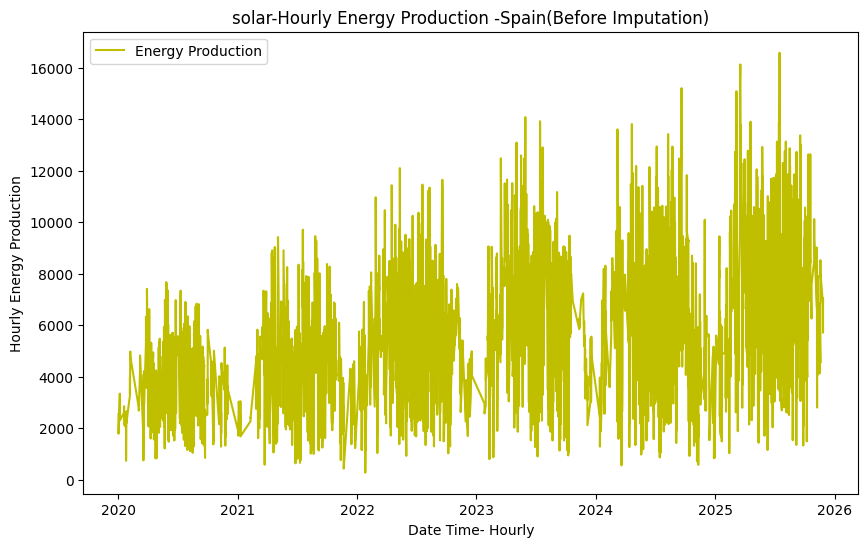

In [19]:
plt.figure(figsize=(10,6))
plt.plot(solar.index ,solar['Production'], color = 'y' ,label = 'Energy Production')
plt.xlabel('Date Time- Hourly')
plt.ylabel('Hourly Energy Production')
plt.title('solar-Hourly Energy Production -Spain(Before Imputation)')
plt.legend(loc= 'best')
plt.show()

### After Imputation

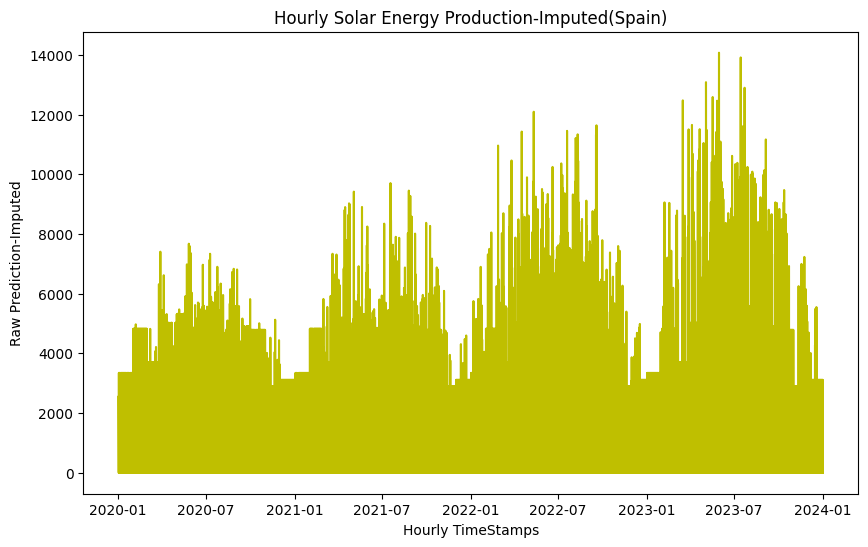

In [20]:
plt.figure(figsize=(10,6))
plt.plot(solar_cleaned.index,solar_cleaned.Production,color = 'y',label='Imputed Raw Prediction')
plt.xlabel('Hourly TimeStamps')
plt.ylabel('Raw Prediction-Imputed')
plt.title('Hourly Solar Energy Production-Imputed(Spain)')
plt.show()

### Log Scale- Before Imputation

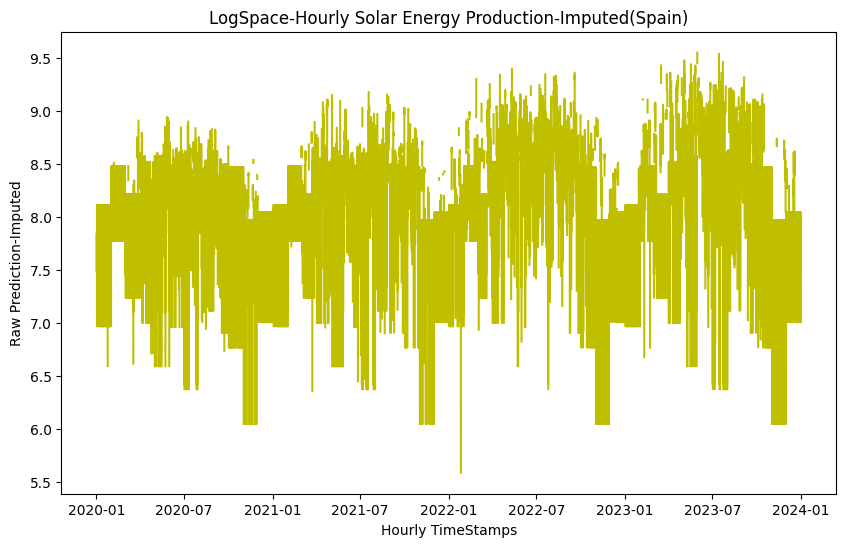

In [21]:
plt.figure(figsize=(10,6))
plt.plot(solar_cleaned.index,solar_cleaned.Production_ln,color = 'y',label='Log Space-Imputed Raw Prediction')
plt.xlabel('Hourly TimeStamps')
plt.ylabel('Raw Prediction-Imputed')
plt.title('LogSpace-Hourly Solar Energy Production-Imputed(Spain)')
plt.show()

### After Imputataion

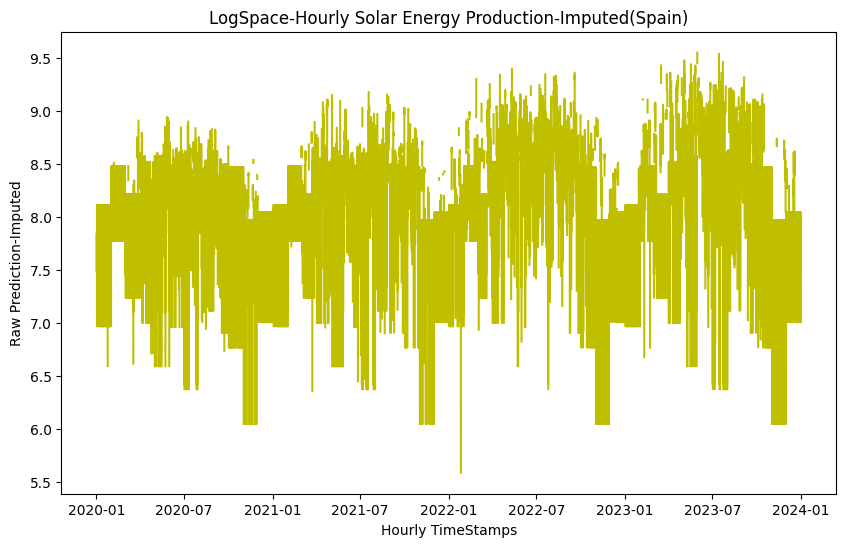

In [22]:
plt.figure(figsize=(10,6))
plt.plot(solar_cleaned.index,solar_cleaned.Production_ln,color = 'y',label='Log Space-Imputed Raw Prediction')
plt.xlabel('Hourly TimeStamps')
plt.ylabel('Raw Prediction-Imputed')
plt.title('LogSpace-Hourly Solar Energy Production-Imputed(Spain)')
plt.show()

## We will proceed for modelling in below order.

Step 1: Build daily solar series (daylight only)

Step 2: Log-transform daily series

Step 3: STL (yearly)

Step 4: ARIMA on remainder

Step 5: Forecast daily totals

Step 6: Redistribute using hourly profile

Step 7: Set night hours to zero

### Step 1: Build daily solar series (daylight only)

In [23]:
daily_solar = solar_cleaned.loc[solar_cleaned['Production'] > 0].groupby(pd.Grouper(freq='D'))['Production'].sum().to_frame(name = 'Solar_production')

### Step 2: Log-transform daily series

In [24]:
daily_solar['ln_Solar_production'] = np.log(daily_solar['Solar_production'])

#### Visualize Imputed Daily Solar Production- train data on original scale and Log scale

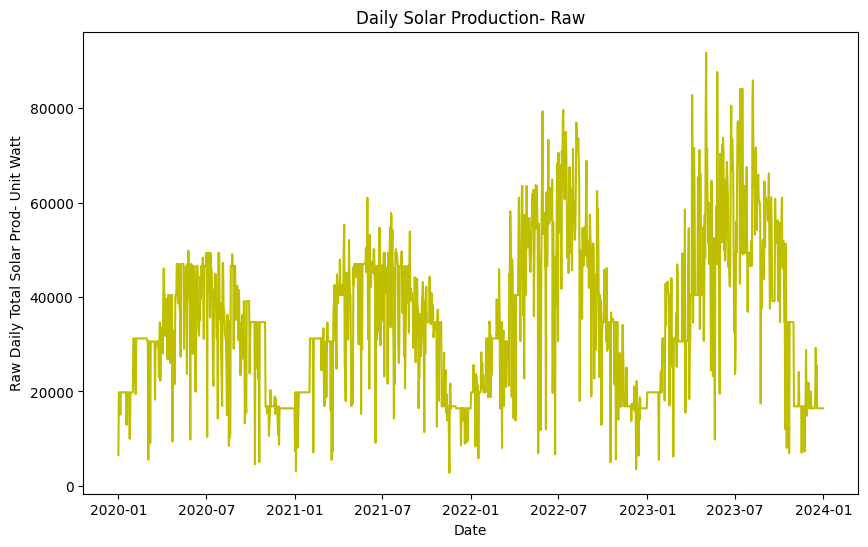

In [25]:
plt.figure(figsize=(10,6))
plt.plot(daily_solar.index,daily_solar['Solar_production'],color = 'y',label = 'Raw-Daily Total Solar Production')
plt.xlabel('Date')
plt.ylabel('Raw Daily Total Solar Prod- Unit Watt')
plt.title('Daily Solar Production- Raw')
plt.show()

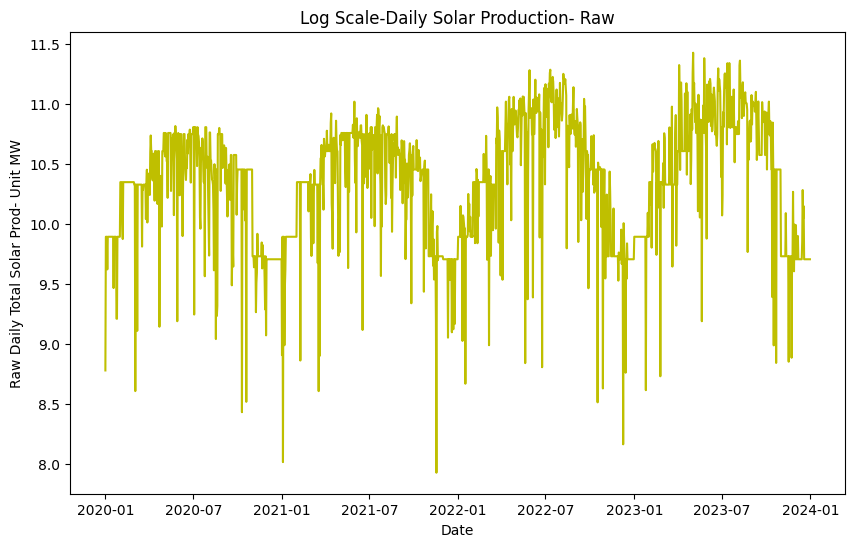

In [26]:
plt.figure(figsize=(10,6))
plt.plot(daily_solar.index,daily_solar['ln_Solar_production'],color = 'y',label = 'Log Scale-Daily Total Solar Production')
plt.xlabel('Date')
plt.ylabel('Raw Daily Total Solar Prod- Unit MW')
plt.title('Log Scale-Daily Solar Production- Raw')
plt.show()

### Step 3: STL (yearly)

In [27]:
from statsmodels.tsa.seasonal import STL

In [28]:
daily_solar = daily_solar.sort_index()
daily_solar = daily_solar.asfreq('D')

In [29]:
daily_solar.isna().sum()

Solar_production       0
ln_Solar_production    0
dtype: int64

No missing data found for daily total series

In [30]:
daily_solar[ daily_solar['ln_Solar_production'] < 0 ].sum() # There should be no -ve

Solar_production       0.0
ln_Solar_production    0.0
dtype: float64

There is no -ve solar production found , this is mendatory since we are modelling in log scale

#### STL Decomposition

In [31]:
daily_stl = STL(daily_solar.ln_Solar_production, period = 365, robust = True)
daily_stl_res = daily_stl.fit()

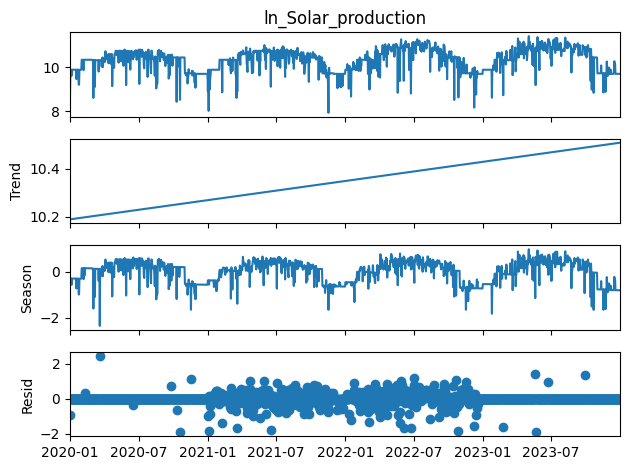

In [32]:
daily_stl_res.plot()
plt.show()

Trend Interpretaion: Monotonic updward growth might be because of installed capacity growth or efficieny imporovement

Season Interpretaion : 
Clear yearly oscilation.
Occasional peaks(downside/upside) may have occured due to sudden weather change or any operational reason 

Residual Interpretaion: No visible seasonality left. Mean ≈ 0 . Some outliers expected due to wweather extreme conditions

In [33]:
daily_solar['Trend']  = daily_stl_res.trend
daily_solar['Seasonal'] = daily_stl_res.seasonal
daily_solar['Residual'] = daily_stl_res.resid

In [34]:
train_seasonal_by_day = (
    daily_stl_res.seasonal
    .groupby(daily_stl_res.seasonal.index.dayofyear)
    .mean()
)

### Step 4: ARIMA on remainder

For modeling residual after STL decomposition, Stationarity check is mandatory. We'll proceed with ADFuller and KPSS test accordingly AR(p) & MA(q) 
p & q will be decided.

#### Stationarity check on Residual

#### ADFuller Test

In [35]:
from statsmodels.tsa.stattools import adfuller

In [36]:
adf_test = adfuller(daily_solar['Residual'].dropna())

In [37]:
adf_df = pd.DataFrame(data = np.column_stack([adf_test[0],adf_test[1],adf_test[4]]), columns=['ADF_Stats','p-Value','Critial_value'])

In [38]:
pd.set_option('display.max_colwidth', None)
adf_df.head()

,ADF_Stats,p-Value,Critial_value
0,-22.97801,0.0,"{'1%': -3.4348399537053482, '5%': -2.8635230163107837, '10%': -2.5678257404326903}"


In [39]:
adf_critical_level = pd.DataFrame(adf_test[4].items() ,columns=['Significance Level', 'Critical Value'] )
adf_critical_level

,Significance Level,Critical Value
0,1%,-3.434840
1,5%,-2.863523
2,10%,-2.567826


ADF Stats is lesser than all critical levels

p-Value<0.05 hence we can reject Ho:Non stationarity

#### KPSS Test

In [40]:
from statsmodels.tsa.stattools import kpss

In [41]:
kpss_res = kpss(daily_solar['Residual'].dropna(), nlags= 'auto' , regression= 'c')
kpss_critical_level = pd.DataFrame(kpss_res[3].items() ,columns=['Significance Level', 'Critical Value'] )
kpss_critical_level

C:\Users\jayjp\AppData\Local\Temp\ipykernel_24852\3539963352.py:1: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




,Significance Level,Critical Value
0,10%,0.347
1,5%,0.463
2,2.5%,0.574
3,1%,0.739


In [42]:
kpss_res_df = pd.DataFrame(data = np.column_stack([kpss_res[0],kpss_res[1]]),columns=['KPSS_STATS','p-Value'])
kpss_res_df

,KPSS_STATS,p-Value
0,0.131627,0.1


p-Value > 0.05 Hence we fail to reject the Ho:Series is stationary

### ARIMA 

##### Selection of AR(p) , MA(q) and d

In [43]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

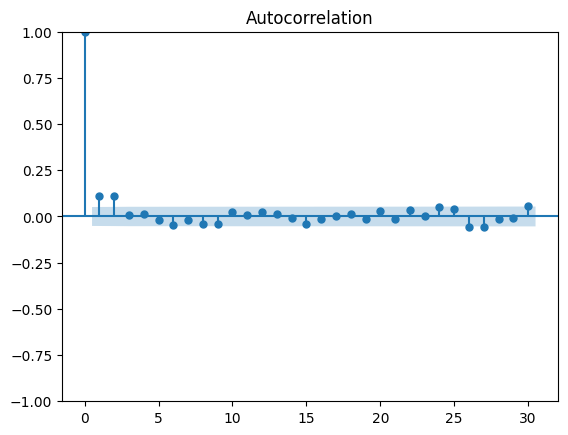

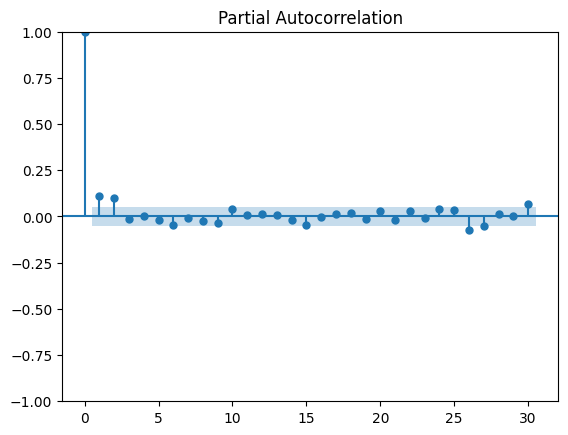

In [44]:
plot_acf(daily_solar["Residual"].dropna(), lags=30)
plot_pacf(daily_solar["Residual"].dropna(), lags=30)
plt.show()

ACF Interpretation : Lag0 is 1 which is expected, Lag = 1 and Lag = 2 and Lag=3 are above c.i. lag>3 is under the c.i. , hence short term memory exists
possibly MA(1) i.e. q=1

PACF Interpretation : Lag0 is 1 which is expected, Lag = 1 and Lag = 2  and Lag=3 are above c.i. lag>3 is under the c.i. , hence short term memory exists 
possiblye AR(1) i.e. p=1

Beyond Lag=3 all are noise.

In [45]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(daily_solar["Residual"].dropna(), lags=[7,14,30])

,lb_stat,lb_pvalue
7,41.664912,6.032397e-07
14,48.925742,9.228454e-06
30,76.587148,6.042101e-06


#### Modelling ARIMA(1,0,1)

In [46]:
from statsmodels.tsa.arima.model import ARIMA

In [47]:
#p, d, q = 1, 0, 0
p, d, q = 1, 0, 1
arima_mod = ARIMA(daily_solar['Residual'],order=(p,d,q),enforce_invertibility=True,enforce_stationarity=True)
arima_res = arima_mod.fit()

In [48]:
arima_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               Residual   No. Observations:                 1461
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -295.716
Date:                Tue, 03 Mar 2026   AIC                            599.432
Time:                        11:02:37   BIC                            620.580
Sample:                    01-01-2020   HQIC                           607.321
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0029      0.010     -0.287      0.774      -0.023       0.017
ar.L1          0.5349      0.127      4.198      0.000       0.285       0.785
ma.L1         -0.4175      0.134     -3.120      0.002      -0.680      -0.155
sigma2         0.0878      0.001     74.277      0.000       0.085       0.090
===================================================================================
Ljung-Box (L1) (Q):                   0.41   Jarque-Bera (JB):             13803.72
Prob(Q):                              0.52   Prob(JB):                         0.00
Heteroskedasticity (H):               0.91   Skew:                            -1.22
Prob(H) (two-sided):                  0.30   Kurtosis:                        17.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [49]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(arima_res.resid, lags=[7,14,30])

,lb_stat,lb_pvalue
7,9.632380,0.210381
14,16.679877,0.273639
30,46.106717,0.030354


##### Model Summary
Ljung Box Test : 
Ho:Residuals are not autocorrelated upto K terms (i.e. white noise)
Prob(Q):0.53 > 0.05 Hence Fail to reject the Ho, hence no significance of autocorrelation this result confirms in ACF plot lag=2 spike(small) was misleading

ar.L1 & ma.L1 for both of these p-value<0.05 hence we can reject Ho: Constant=0. Lag 1 shows short term memory auto correlation

AIC = 593.069  , AIC=−2log(L)+2k
BIC	= 614.217    , BIC= -2log(L) + klog(n)

L = likelihood of the fitted model𝑘 ,
k = number of estimated parameters ,
n = number of observations

n=2161 , k =4 , L= -292.535

Heteroskedasticity (H): 0.91
Prob(H)               : 0.29
Underline Ho: Residual Variance constant over time (Homoskedastic) , p-value = 0.29> 0.05 hence fail to reject Ho. No need of variance modelling (GARCH)

##### Trying ARIMA (p,d,q) -> (2,0,2) based in ACF/PACF plot visuals

In [50]:
#p,d,q=1,0,1
p,d,q=2,0,2
arima_mod_2 = ARIMA(daily_solar['Residual'],order=(p,d,q),enforce_invertibility=True,enforce_stationarity=True)
arima_res2 = arima_mod_2.fit()

In [51]:
arima_res2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               Residual   No. Observations:                 1461
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -292.435
Date:                Tue, 03 Mar 2026   AIC                            596.869
Time:                        11:02:37   BIC                            628.591
Sample:                    01-01-2020   HQIC                           608.702
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0029      0.010     -0.289      0.773      -0.023       0.017
ar.L1         -0.0689      0.259     -0.266      0.790      -0.576       0.438
ar.L2          0.1310      0.211      0.621      0.535      -0.283       0.545
ma.L1          0.1721      0.261      0.660      0.509      -0.339       0.683
ma.L2         -0.0097      0.198     -0.049      0.961      -0.398       0.378
sigma2         0.0874      0.001     72.913      0.000       0.085       0.090
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             13625.00
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.91   Skew:                            -1.21
Prob(H) (two-sided):                  0.30   Kurtosis:                        17.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
acorr_ljungbox(arima_res2.resid, lags=[7,14,30])

,lb_stat,lb_pvalue
7,2.917182,0.892556
14,9.794138,0.777074
30,38.572372,0.135601


##### Comparision

AIC and BIC both have increased in AR(2), MA(2) model and also all additional parameters are statistically insignificant

### Forecast

In [53]:
import numpy as np
import pandas as pd


def forecast_solar(
    df: pd.DataFrame,
    train_seasonal_by_day: pd.Series,
    arima_model,
    train_trend: pd.Series,
    production_col_name: str = "Production",
    mode: str = "forecast",  # "fit" or "forecast"
    bias_correct: bool = True,
) -> pd.DataFrame:
    """
    Daily solar forecast using:
    STL trend (extrapolated) + seasonal profile + ARIMA residual model.

    Parameters
    ----------
    df : pd.DataFrame
        Hourly dataframe (DatetimeIndex required)
    train_seasonal_by_day : pd.Series
        Seasonal component indexed by day-of-year (1–366)
    arima_model : fitted ARIMA results object
        ARIMA model trained on daily STL residual
    train_trend : pd.Series
        STL trend component from training period
    production_col_name : str
        Name of production column
    mode : str
        "fit" → use in-sample ARIMA fitted values
        "forecast" → use ARIMA forecast for horizon
    bias_correct : bool
        Apply log-normal bias correction

    Returns
    -------
    pd.DataFrame
        Daily dataframe with forecast components
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("df must have DatetimeIndex")

    if mode not in ["fit", "forecast"]:
        raise ValueError("mode must be 'fit' or 'forecast'")

    df = df.copy()

    # ---- 1️⃣ Daily aggregation ----
    daily = (
        df.groupby(pd.Grouper(freq="D"))[production_col_name]
        .sum()
        .to_frame("Solar_production")
    )

    # ---- 2️⃣ Log transform safely ----
    daily["ln_Solar_production"] = np.nan
    mask = daily["Solar_production"] > 0
    daily.loc[mask, "ln_Solar_production"] = np.log(
        daily.loc[mask, "Solar_production"]
    )

    # ---- 3️⃣ Seasonal mapping ----
    daily["seasonal"] = daily.index.dayofyear.map(
        train_seasonal_by_day
    )

    # ---- 4️⃣ Residual component ----
    h = len(daily)

    if mode == "fit":
        resid_component = arima_model.fittedvalues
    else:
        resid_component = arima_model.forecast(steps=h)

    daily["arima_component"] = resid_component.values

    # ---- 5️⃣ Trend extrapolation ----
    last_trend = train_trend.iloc[-1]
    slope = train_trend.diff().median()

    trend_extrapolated = last_trend + slope * np.arange(1, h + 1)
    daily["trend"] = trend_extrapolated

    # ---- 6️⃣ Compose log forecast ----
    daily["ln_forecast"] = (
        daily["trend"].values
        + daily["seasonal"].values
        + daily["arima_component"].values
    )

    # ---- 7️⃣ Bias correction ----
    if bias_correct:
        sigma2 = arima_model.params.get("sigma2", 0)
        daily["forecast"] = np.exp(
            daily["ln_forecast"] + 0.5 * sigma2
        )
    else:
        daily["forecast"] = np.exp(daily["ln_forecast"])

    return daily

#### Forecast on Train dataset

In [54]:
daily_train = forecast_solar(
    df=train,
    train_seasonal_by_day=train_seasonal_by_day,
    arima_model=arima_res,
    train_trend=daily_stl_res.trend,
    mode="fit"
)

<Axes: >

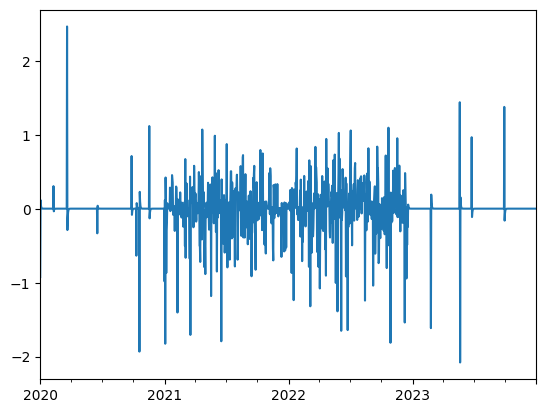

In [55]:
(arima_res.resid).plot()

<Axes: >

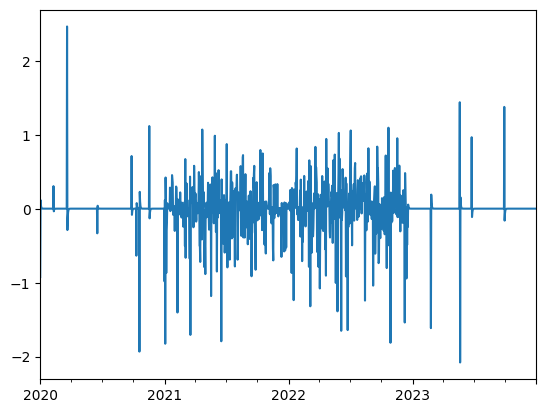

In [56]:
stl_resid = daily_stl_res.resid
arima_fit = arima_res.fittedvalues

(stl_resid - arima_fit).plot()

In [57]:
(stl_resid - arima_fit).mean()

0.0001404277034810101

##### The series shows:

Strong variance during 2021–2023

Large negative spikes (~ -2)

Some positive spikes (~ +1.3)

Flat zero segments at edges (likely filtered low-production periods)

##### Interpretation:

1. Heteroskedasticity present
Variance is not constant over time. ARIMA assumes homoskedastic errors — this assumption is violated.

2. Outliers dominate error structure
    Those deep negative spikes are likely:
    
        Cloudy extreme days
        
        Curtailment
        
        Data quality issues
        
        Ramp failures

3. Model captures central tendency but not extremes
    Mean is near zero → good.
    Variance is large → tail behavior not modeled well.

. This is very close to zero, which indicates:

. No significant systematic bias

. ARIMA is not consistently over- or under-predicting the residual component

. Mean correction is essentially calibrated

### Conclusion

What This Implies for Solar Forecasting Framework

Given your workflow (seasonal median + ARIMA on residual):

    1. Seasonal structure is handled well.
    
    2. ARIMA is modeling smooth deviations.
    
    3. Extreme deviations remain unexplained noise.

In [58]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(stl_resid - arima_fit, lags=[7,14,30])

,lb_stat,lb_pvalue
7,9.632380,0.210381
14,16.679877,0.273639
30,46.106717,0.030354


In [59]:
(stl_resid - arima_fit).std()

0.29637361635456994

#### Forecast on Validation dataset

In [60]:
# Daily Forecast on validation dataset
daily_val = forecast_solar(
    df=val,
    train_seasonal_by_day=train_seasonal_by_day,
    arima_model=arima_res,
    train_trend=daily_stl_res.trend,
    mode="forecast"
)

In [61]:
## Daily Forecast on test dataset
daily_test = forecast_solar(
    df=test,
    train_seasonal_by_day=train_seasonal_by_day,
    arima_model=arima_res,
    train_trend=daily_stl_res.trend,
    mode="forecast"
)

## Forecast Evaluation

In [62]:
from sklearn.metrics import mean_absolute_percentage_error,mean_absolute_error,root_mean_squared_error

In [63]:
observed_val_mask = daily_val['Solar_production'] > 0
observed_test_mask = daily_test['Solar_production'] > 0

In [64]:
mape_daily_val = mean_absolute_percentage_error(daily_val.loc[observed_val_mask]['Solar_production'], daily_val.loc[observed_val_mask]['forecast'])
mape_daily_val

0.41190234311714546

In [65]:
mape_daily_test = mean_absolute_percentage_error(daily_test.loc[observed_test_mask]['Solar_production'], daily_test.loc[observed_test_mask]['forecast'])
mape_daily_test

0.40441858749600607

In [66]:
mae_daily_val = mean_absolute_error(daily_val.loc[observed_val_mask]['Solar_production'], daily_val.loc[observed_val_mask]['forecast'])
mae_daily_val

14115.452086250294

In [67]:
mae_daily_test = mean_absolute_error(daily_test.loc[observed_test_mask]['Solar_production'], daily_test.loc[observed_test_mask]['forecast'])
mae_daily_test

19706.98933454955

In [68]:
rmse_daily_val =  root_mean_squared_error(daily_val.loc[observed_val_mask]['Solar_production'], daily_val.loc[observed_val_mask]['forecast'])
rmse_daily_val

18228.94972242991

In [69]:
rmse_daily_test =  root_mean_squared_error(daily_test.loc[observed_test_mask]['Solar_production'], daily_test.loc[observed_test_mask]['forecast'])
rmse_daily_test

24125.387575259283

## Bias Diagnosis

In [70]:
bias_val = (daily_val.loc[observed_val_mask]['forecast'] - daily_val.loc[observed_val_mask]['Solar_production']).mean()
bias_val

-2188.353402396749

In [71]:
bias_test = (daily_test.loc[observed_test_mask]['forecast'] - daily_test.loc[observed_test_mask]['Solar_production']).mean()
bias_test

-10424.604398885678

In [72]:
bias_pct_val = bias_val / daily_val.loc[observed_val_mask]["Solar_production"].mean() * 100
bias_pct_val

-4.452059166198147

In [73]:
# Naya wala 2021-2024
bias_pct_test = bias_test / daily_test.loc[observed_test_mask]["Solar_production"].mean() * 100
bias_pct_test

-17.786211140838667

<Axes: title={'center': 'Forecast to Actual production Ratio in Original Scale- Before Trend Extrapolaton'}, xlabel='Date', ylabel='Numerical Ratio'>

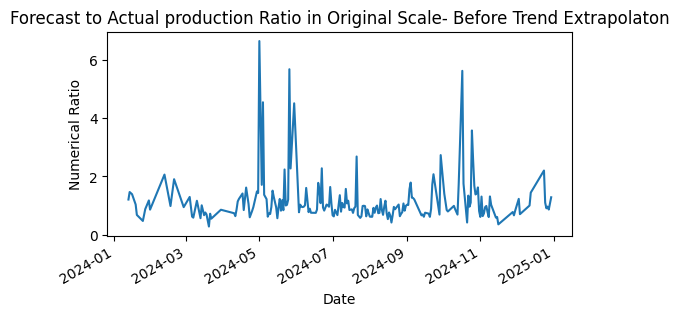

In [74]:
plt.figure(figsize=(6,3))
plt.xlabel('Date')
plt.ylabel('Numerical Ratio')
plt.title("Forecast to Actual production Ratio in Original Scale- Before Trend Extrapolaton")
(daily_val.loc[observed_val_mask]["forecast"] / daily_val.loc[observed_val_mask]["Solar_production"]).plot()

Underforecast during high production months

<Axes: title={'center': 'Forecast to Actual production Ratio in Original Scale- Before Trend Extrapolaton'}, xlabel='Date', ylabel='Numerical Ratio'>

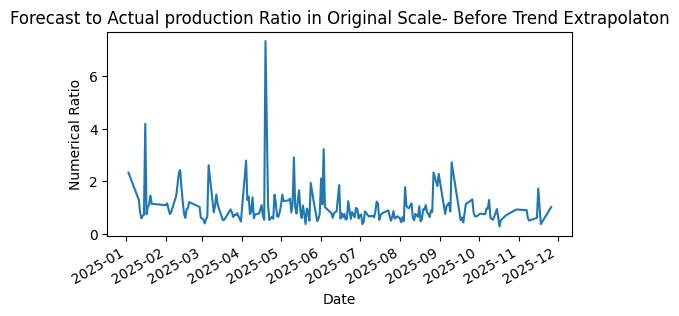

In [75]:
# # Naya wala 2021-2024
plt.figure(figsize=(6,3))
plt.xlabel('Date')
plt.ylabel('Numerical Ratio')
plt.title("Forecast to Actual production Ratio in Original Scale- Before Trend Extrapolaton")
(daily_test.loc[observed_test_mask]["forecast"] / daily_test.loc[observed_test_mask]["Solar_production"]).plot()

In [76]:
smape_val = np.mean(
    2 * np.abs(daily_val.loc[observed_val_mask]['forecast'] - daily_val.loc[observed_val_mask]['Solar_production']) / (np.abs(daily_val.loc[observed_val_mask]['forecast']) + np.abs(daily_val.loc[observed_val_mask]['Solar_production']))
)
smape_val

0.3189903525377617

In [77]:
smape_test = np.mean(
    2 * np.abs(daily_test.loc[observed_test_mask]['forecast'] - daily_test.loc[observed_test_mask]['Solar_production']) / (np.abs(daily_test.loc[observed_test_mask]['forecast']) + np.abs(daily_test.loc[observed_test_mask]['Solar_production']))
)
smape_test

0.37469774328730837

In [78]:
print("Validation Bias-> ",bias_val)
print("Validation Bias Percentage-> ",bias_pct_val)

Validation Bias->  -2188.353402396749
Validation Bias Percentage->  -4.452059166198147


In [79]:
print("Test Bias-> ",bias_test)
print("Test Bias Percentage-> ",bias_pct_test)

Test Bias->  -10424.604398885678
Test Bias Percentage->  -17.786211140838667


[]

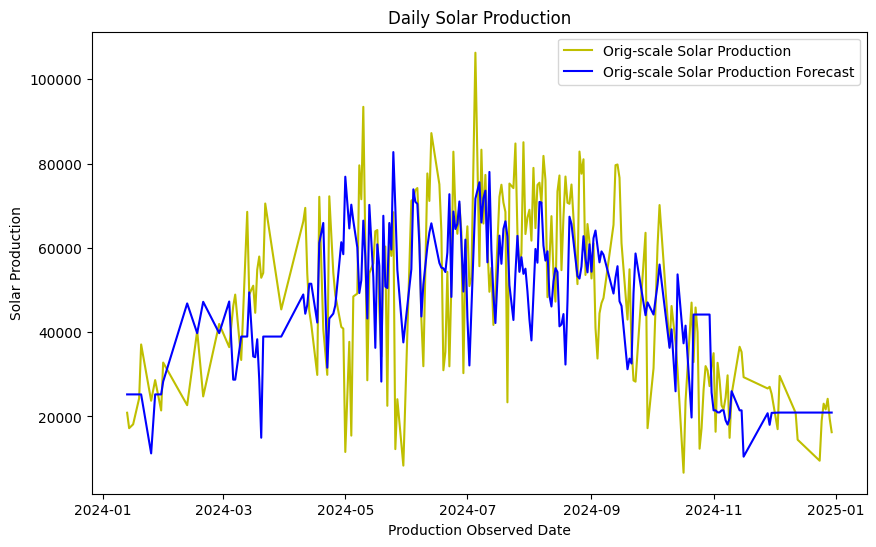

In [80]:
plt.figure(figsize=(10,6))
plt.plot(daily_val[observed_val_mask].index, daily_val[observed_val_mask]['Solar_production'] , color ='y' , label ='Orig-scale Solar Production')
plt.plot(daily_val[observed_val_mask].index, daily_val[observed_val_mask]['forecast'],  color ='b' , label ='Orig-scale Solar Production Forecast')
plt.xlabel('Production Observed Date')
plt.ylabel('Solar Production')
plt.title('Daily Solar Production')
plt.legend(loc= 'best')
plt.plot()

[]

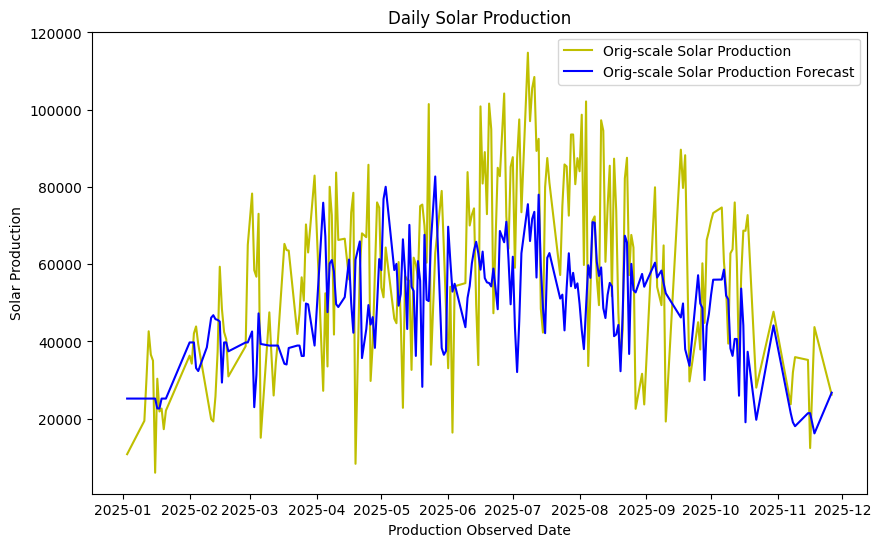

In [81]:
plt.figure(figsize=(10,6))
plt.plot(daily_test[observed_test_mask].index, daily_test[observed_test_mask]['Solar_production'] , color ='y' , label ='Orig-scale Solar Production')
plt.plot(daily_test[observed_test_mask].index, daily_test[observed_test_mask]['forecast'],  color ='b' , label ='Orig-scale Solar Production Forecast')
plt.xlabel('Production Observed Date')
plt.ylabel('Solar Production')
plt.title('Daily Solar Production')
plt.legend(loc= 'best')
plt.plot()

## Hourly Solar Forecast- Mapping hourly weight

In [82]:
val_hourly = hourly_mapping(
    df = val ,
    hourly_weights = hourly_weights,
    daily_forecast = daily_val['forecast'] ,
    production_col = "Production"
)
val_hourly = val_hourly[val_hourly['Production'].notna()]

In [83]:
test_hourly = hourly_mapping(
    df = test ,
    hourly_weights = hourly_weights,
    daily_forecast = daily_test['forecast'] ,
    production_col = "Production"
)
test_hourly = test_hourly[test_hourly['Production'].notna()]

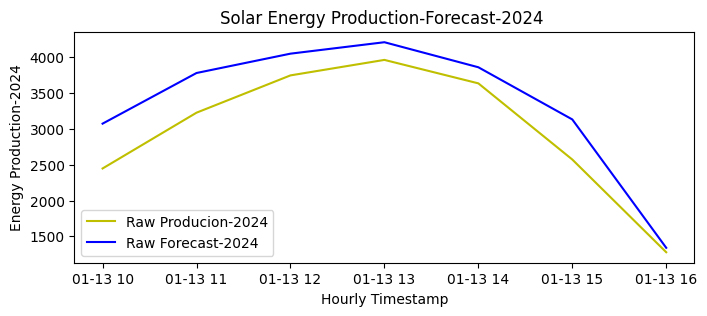

In [84]:
month = 1
day = 13
plt.figure(figsize=(8,3))
plt.plot(val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)].index,val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['Production'], color = 'y' , label = 'Raw Producion-2024')
plt.plot(val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)].index,val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['forecast_hourly'], color = 'b' , label = 'Raw Forecast-2024')
plt.xlabel('Hourly Timestamp')
plt.ylabel('Energy Production-2024')
plt.title("Solar Energy Production-Forecast-2024 ")
plt.legend(loc='best')
plt.show()

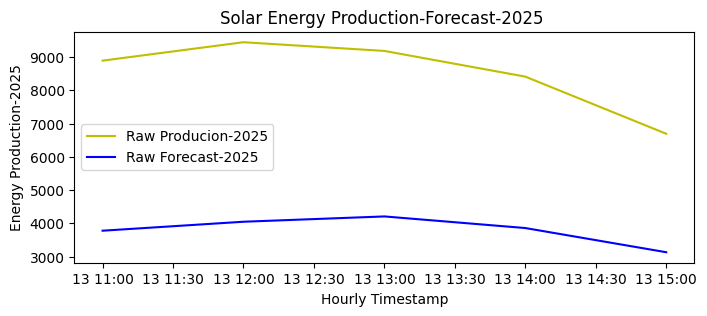

In [85]:
month = 1
day = 13
plt.figure(figsize=(8,3))
plt.plot(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)].index,test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['Production'], color = 'y' , label = 'Raw Producion-2025')
plt.plot(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)].index,test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['forecast_hourly'], color = 'b' , label = 'Raw Forecast-2025')
plt.xlabel('Hourly Timestamp')
plt.ylabel('Energy Production-2025')
plt.title("Solar Energy Production-Forecast-2025 ")
plt.legend(loc='best')
plt.show()

### Overall evaluation on 2024 (validation dataset) Solar Production data

In [86]:
root_mean_squared_error(val_hourly['Production'],val_hourly['forecast_hourly'])

2505.9727651815233

In [87]:
mean_absolute_percentage_error(val_hourly['Production'],val_hourly['forecast_hourly'])

0.3067037022020804

In [88]:
mean_absolute_error(val_hourly['Production'],val_hourly['forecast_hourly'])

1922.3660901504668

In [89]:
smape_val = np.mean(
    2 * np.abs(val_hourly['forecast_hourly'] - val_hourly['Production']) / (np.abs(val_hourly['forecast_hourly']) + np.abs(val_hourly['Production']))
)
smape_val

0.3514940270423423

### Overall evaluation on 2025(test dataset) Solar Production data

In [90]:
root_mean_squared_error(test_hourly['Production'],test_hourly['forecast_hourly'])

3544.3370990638446

In [91]:
mean_absolute_percentage_error(test_hourly['Production'],test_hourly['forecast_hourly'])

0.3772593582490152

In [92]:
mean_absolute_error(test_hourly['Production'],test_hourly['forecast_hourly'])

2904.2442627093983

In [93]:
smape_val = np.mean(
    2 * np.abs(test_hourly['forecast_hourly'] - test_hourly['Production']) / (np.abs(test_hourly['forecast_hourly']) + np.abs(test_hourly['Production']))
)
smape_val

0.46628539237972755

### Evaluation for a day- 13th Jan 2025

In [94]:
root_mean_squared_error(val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['Production'],val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['forecast_hourly'])

416.83779572293184

In [95]:
root_mean_squared_error(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['Production'],test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['forecast_hourly'])

4766.56199223288

In [96]:
mean_absolute_percentage_error(val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['Production'],val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['forecast_hourly'])

0.1282311353164368

In [97]:
mean_absolute_percentage_error(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['Production'],test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['forecast_hourly'])

0.5525198227825696

## How much of hourly error is caused purely by daily bias?

In [98]:
actual_sum = daily_val.loc[observed_val_mask, 'Solar_production'].sum()
forecast_sum = daily_val.loc[observed_val_mask, 'forecast'].sum()

print("Actual sum:", actual_sum)
print("Forecast sum:", forecast_sum)
print("Ratio:", forecast_sum / actual_sum)

print("Bias pct recomputed:",
      (forecast_sum - actual_sum) / actual_sum * 100)

Actual sum: 10420592.0
Forecast sum: 9956661.078691889
Ratio: 0.9554794083380185
Bias pct recomputed: -4.452059166198152


In [99]:
bias_ratio_val = (
    daily_val.loc[observed_val_mask, 'forecast'].sum()
    / daily_val.loc[observed_val_mask, 'Solar_production'].sum()
)

print("Validation bias ratio:", bias_ratio_val)

Validation bias ratio: 0.9554794083380185


Validation bias ratio: 0.9554794083380185

In [100]:
daily_test['forecast_corrected'] = (
    daily_test['forecast'] / bias_ratio_val
)

In [101]:
mape_test_old = mean_absolute_percentage_error(
    daily_test.loc[observed_test_mask, 'Solar_production'],
    daily_test.loc[observed_test_mask, 'forecast']
)

rmse_test_old = root_mean_squared_error(
    daily_test.loc[observed_test_mask, 'Solar_production'],
    daily_test.loc[observed_test_mask, 'forecast']
)

bias_test_old = (
    daily_test.loc[observed_test_mask, 'forecast']
    - daily_test.loc[observed_test_mask, 'Solar_production']
).mean()

bias_pct_test_old = (
    bias_test_old
    / daily_test.loc[observed_test_mask, 'Solar_production'].mean()
    * 100
)

print("Corrected Test MAPE:", mape_test_old)
print("Corrected Test RMSE:", rmse_test_old)
print("Corrected Test Bias %:", bias_pct_test_old)

Corrected Test MAPE: 0.40441858749600607
Corrected Test RMSE: 24125.387575259283
Corrected Test Bias %: -17.786211140838667


In [102]:
mape_test_corrected = mean_absolute_percentage_error(
    daily_test.loc[observed_test_mask, 'Solar_production'],
    daily_test.loc[observed_test_mask, 'forecast_corrected']
)

rmse_test_corrected = root_mean_squared_error(
    daily_test.loc[observed_test_mask, 'Solar_production'],
    daily_test.loc[observed_test_mask, 'forecast_corrected']
)

bias_test_corrected = (
    daily_test.loc[observed_test_mask, 'forecast_corrected']
    - daily_test.loc[observed_test_mask, 'Solar_production']
).mean()

bias_pct_test_corrected = (
    bias_test_corrected
    / daily_test.loc[observed_test_mask, 'Solar_production'].mean()
    * 100
)

print("Corrected Test MAPE:", mape_test_corrected)
print("Corrected Test RMSE:", rmse_test_corrected)
print("Corrected Test Bias %:", bias_pct_test_corrected)

Corrected Test MAPE: 0.4083215735977645
Corrected Test RMSE: 23371.934140157497
Corrected Test Bias %: -13.955457185450213


In [103]:
test_hourly_corrected = hourly_mapping(
    df = test ,
    hourly_weights = hourly_weights,
    daily_forecast = daily_test['forecast_corrected'] ,
    production_col = "Production"
)
test_hourly_corrected = test_hourly_corrected[test_hourly_corrected['Production'].notna()]

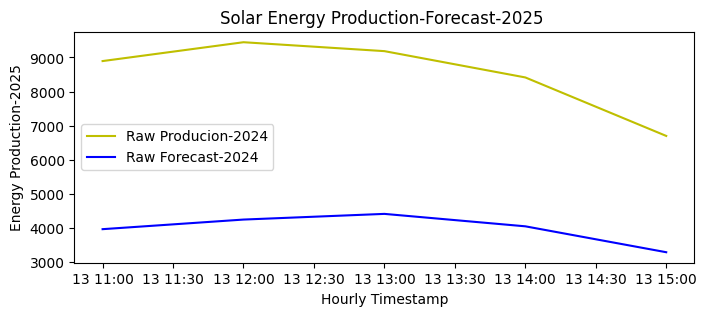

In [104]:
month = 1
day = 13
plt.figure(figsize=(8,3))
plt.plot(test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)].index,test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['Production'], color = 'y' , label = 'Raw Producion-2024')
plt.plot(test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)].index,test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['forecast_hourly'], color = 'b' , label = 'Raw Forecast-2024')
plt.xlabel('Hourly Timestamp')
plt.ylabel('Energy Production-2025')
plt.title("Solar Energy Production-Forecast-2025 ")
plt.legend(loc='best')
plt.show()

In [105]:
root_mean_squared_error(test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['Production'],test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['forecast_hourly'])

4588.894252958564

In [106]:
mean_absolute_percentage_error(test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['Production'],test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['forecast_hourly'])

0.5316694705165996

We see a 2% improvement in MAPE and 3% improvement in RMSE

### Overall evaluation on 2024 Validation data

In [107]:
daily_val['forecast_corrected'] = (
    daily_val['forecast'] / bias_ratio_val
)

In [108]:
val_hourly_corrected = hourly_mapping(
    df = val ,
    hourly_weights = hourly_weights,
    daily_forecast = daily_val['forecast_corrected'] ,
    production_col = "Production"
)
val_hourly_corrected = val_hourly_corrected[val_hourly_corrected['Production'].notna()]

In [109]:
root_mean_squared_error(val_hourly_corrected['Production'],val_hourly_corrected['forecast_hourly'])

2399.286352660762

In [110]:
mean_absolute_percentage_error(val_hourly_corrected['Production'],val_hourly_corrected['forecast_hourly'])

0.297129954803438

In [111]:
mean_absolute_error(val_hourly_corrected['Production'],val_hourly_corrected['forecast_hourly'])

1823.1971139599216

In [112]:
smape_test = np.mean(
    2 * np.abs(val_hourly_corrected['forecast_hourly'] - val_hourly_corrected['Production']) / (np.abs(val_hourly_corrected['forecast_hourly']) + np.abs(val_hourly_corrected['Production']))
)
smape_test

0.32972637084590684

## Calculate validation_bias_ratio on hourly forecast

In [113]:
hourly_bias_ratio_val = (
    val_hourly_corrected['forecast_hourly'].sum()
    / val_hourly_corrected['Production'].sum()
)

print("Validation bias ratio:", hourly_bias_ratio_val)

Validation bias ratio: 0.8060832505953306


Validation bias ratio: 0.8060832505953306

#### Apply correction

In [114]:
val_hourly_corrected['forecast_corrected'] = (
    val_hourly_corrected['forecast_hourly'] / hourly_bias_ratio_val
)

### Evaluate post correction

In [115]:
root_mean_squared_error(val_hourly_corrected['Production'],val_hourly_corrected['forecast_corrected'])

2203.6620144942285

In [116]:
mean_absolute_percentage_error(val_hourly_corrected['Production'],val_hourly_corrected['forecast_corrected'])

0.3167660891791422

In [117]:
mean_absolute_error(val_hourly_corrected['Production'],val_hourly_corrected['forecast_corrected'])

1699.9550316732561

In [118]:
smape_test = np.mean(
    2 * np.abs(val_hourly_corrected['forecast_corrected'] - val_hourly_corrected['Production']) / (np.abs(val_hourly_corrected['forecast_corrected']) + np.abs(val_hourly_corrected['Production']))
)
smape_test

0.2884791805496897

### Overall evaluation on 2025 Test data

In [119]:
root_mean_squared_error(test_hourly_corrected['Production'],test_hourly_corrected['forecast_hourly'])

3404.3040601022735

In [120]:
mean_absolute_percentage_error(test_hourly_corrected['Production'],test_hourly_corrected['forecast_hourly'])

0.36460421228439577

In [121]:
mean_absolute_error(test_hourly_corrected['Production'],test_hourly_corrected['forecast_hourly'])

2774.5737931049152

In [122]:
smape_test = np.mean(
    2 * np.abs(test_hourly_corrected['forecast_hourly'] - test_hourly_corrected['Production']) / (np.abs(test_hourly_corrected['forecast_hourly']) + np.abs(test_hourly_corrected['Production']))
)
smape_test

0.4394760370366287

4% Increment in RMSE, 1% Increment in MAPE , 4% Increment in MAE, 3 % improvement in SMAPE after bias correction used from validation dataset

### Apply bias correction from hourly forecasted validation dataset on test hourly forecasted

In [123]:
test_hourly_corrected['forecast_corrected'] = (
    test_hourly_corrected['forecast_hourly'] / hourly_bias_ratio_val
)

In [124]:
hourly_bias_ratio_val

0.8060832505953306

hourly_bias_ratio_val- 0.8060832505953306

### Evaluate post correction

In [125]:
root_mean_squared_error(test_hourly_corrected['Production'],test_hourly_corrected['forecast_corrected'])

2880.1429370460355

In [126]:
mean_absolute_percentage_error(test_hourly_corrected['Production'],test_hourly_corrected['forecast_corrected'])

0.32629901416570767

In [127]:
mean_absolute_error(test_hourly_corrected['Production'],test_hourly_corrected['forecast_corrected'])

2260.5732070926415

In [128]:
smape_test = np.mean(
    2 * np.abs(test_hourly_corrected['forecast_corrected'] - test_hourly_corrected['Production']) / (np.abs(test_hourly_corrected['forecast_corrected']) + np.abs(test_hourly_corrected['Production']))
)
smape_test

0.3352772595690722

[]

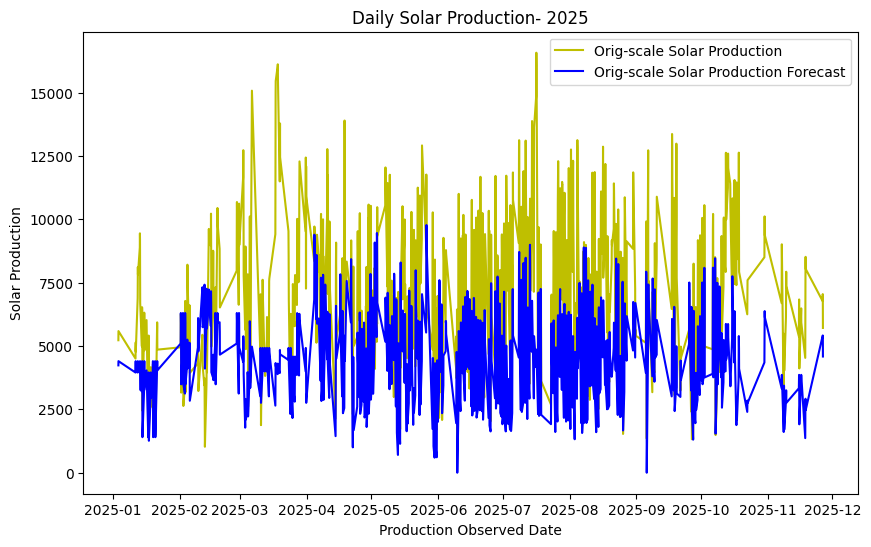

In [129]:
plt.figure(figsize=(10,6))
plt.plot(test_hourly_corrected.index, test_hourly_corrected['Production'] , color ='y' , label ='Orig-scale Solar Production')
plt.plot(test_hourly_corrected.index, test_hourly_corrected['forecast_hourly'],  color ='b' , label ='Orig-scale Solar Production Forecast')
plt.xlabel('Production Observed Date')
plt.ylabel('Solar Production')
plt.title('Daily Solar Production- 2025')
plt.legend(loc= 'best')
plt.plot()

[]

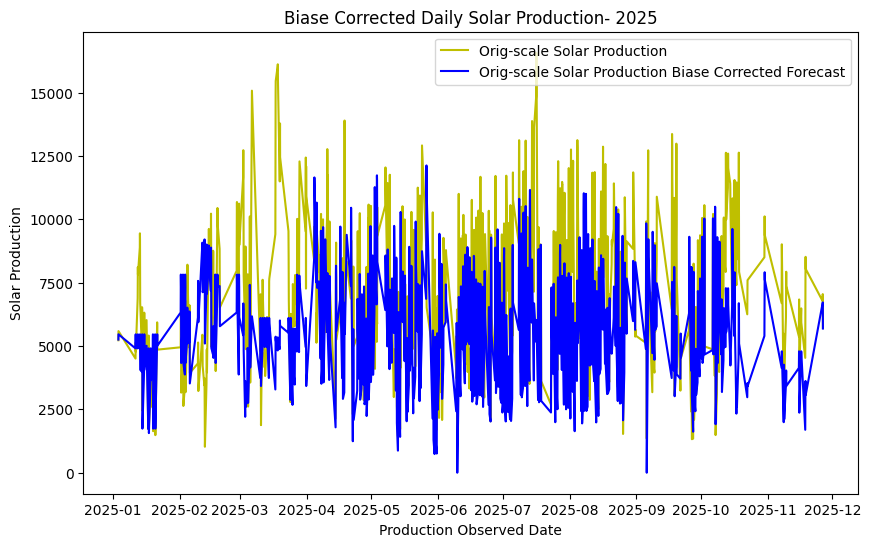

In [130]:
plt.figure(figsize=(10,6))
plt.plot(test_hourly_corrected.index, test_hourly_corrected['Production'] , color ='y' , label ='Orig-scale Solar Production')
plt.plot(test_hourly_corrected.index, test_hourly_corrected['forecast_corrected'],  color ='b' , label ='Orig-scale Solar Production Biase Corrected Forecast')
plt.xlabel('Production Observed Date')
plt.ylabel('Solar Production')
plt.title('Biase Corrected Daily Solar Production- 2025')
plt.legend(loc= 'best')
plt.plot()

Let us call this one solar model- we'll name it "solar_STL_ARIMA_2020_2023_bias_corrected_model"

In [131]:
def generate_final_hourly_forecast(
    test_df,
    forecast_fn,
    hourly_mapping_fn,
    train_seasonal_by_day,
    arima_model,
    train_trend,
    hourly_weights,
    daily_bias_ratio,
    hourly_bias_ratio,
    production_col="Production"
):
    """
    Generates final bias-corrected hourly forecast
    with both daily and hourly bias adjustment.

    Pipeline:
    1. Daily forecast
    2. Daily bias correction
    3. Hourly mapping
    4. Hourly bias correction

    Returns
    -------
    hourly_forecast : pd.DataFrame
    daily_forecast  : pd.DataFrame
    """

    # ---------------------------
    # Step 1: Daily Forecast
    # ---------------------------
    daily_test = forecast_fn(
        df=test_df,
        train_seasonal_by_day=train_seasonal_by_day,
        arima_model=arima_model,
        train_trend=train_trend,
        mode="forecast"
    )

    # ---------------------------
    # Step 2: Daily Bias Correction
    # ---------------------------
    daily_test["forecast_corrected"] = (
        daily_test["forecast"] / daily_bias_ratio
    )

    # ---------------------------
    # Step 3: Hourly Mapping
    # ---------------------------
    hourly_forecast = hourly_mapping_fn(
        df=test_df,
        hourly_weights=hourly_weights,
        daily_forecast=daily_test["forecast_corrected"],
        production_col=production_col
    )

    # Remove rows without actual production
    hourly_forecast = hourly_forecast[
        hourly_forecast[production_col].notna()
    ]

    # ---------------------------
    # Step 4: Hourly Bias Correction
    # ---------------------------
    hourly_forecast["forecast_final"] = (
        hourly_forecast["forecast_hourly"] / hourly_bias_ratio
    )

    return hourly_forecast, daily_test

In [132]:
import numpy as np
import pandas as pd

def evaluate_forecast(
    df,
    actual_col="Production",
    forecast_col="forecast_corrected",
    drop_zero_actual_for_mape=True
):
    """
    Evaluate forecast performance on full dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Data containing actual and forecast columns
    actual_col : str
        Column name for actual values (e.g., 'Production')
    forecast_col : str
        Column name for forecast values (e.g., 'forecast_corrected')
    drop_zero_actual_for_mape : bool
        If True, removes zero-actual rows for MAPE calculation
        (recommended for solar night hours)

    Returns
    -------
    dict containing RMSE, MAE, MAPE, SMAPE
    """

    data = df[[actual_col, forecast_col]].dropna().copy()

    y_true = data[actual_col].values
    y_pred = data[forecast_col].values

    # -------------------------
    # Error Terms
    # -------------------------
    error = y_true - y_pred
    abs_error = np.abs(error)

    # -------------------------
    # RMSE
    # -------------------------
    rmse = np.sqrt(np.mean(error ** 2))

    # -------------------------
    # MAE
    # -------------------------
    mae = np.mean(abs_error)

    # -------------------------
    # MAPE
    # -------------------------
    if drop_zero_actual_for_mape:
        mask = y_true != 0
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.mean(np.abs(error / y_true)) * 100

    # -------------------------
    # SMAPE
    # -------------------------
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    nonzero_mask = denominator != 0
    smape = np.mean(abs_error[nonzero_mask] / denominator[nonzero_mask]) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "SMAPE (%)": smape
    }

In [133]:
daily_bias_ratio_val  = 0.9554794083380185
hourly_bias_ratio_val = 0.8060832505953306

final_hourly_forecast, daily_test = generate_final_hourly_forecast(
    test_df=test,
    forecast_fn=forecast_solar,
    hourly_mapping_fn=hourly_mapping,
    train_seasonal_by_day=train_seasonal_by_day,
    arima_model=arima_res,
    train_trend=daily_stl_res.trend,
    hourly_weights=hourly_weights,
    daily_bias_ratio=daily_bias_ratio_val,
    hourly_bias_ratio=hourly_bias_ratio_val,
    production_col="Production"
)

In [134]:
metrics = evaluate_forecast(
    df=final_hourly_forecast,
    actual_col="Production",
    forecast_col="forecast_final"
)

print(metrics)

{'RMSE': 2880.1429370460355, 'MAE': 2260.5732070926415, 'MAPE (%)': 32.62990141657077, 'SMAPE (%)': 33.52772595690722}
